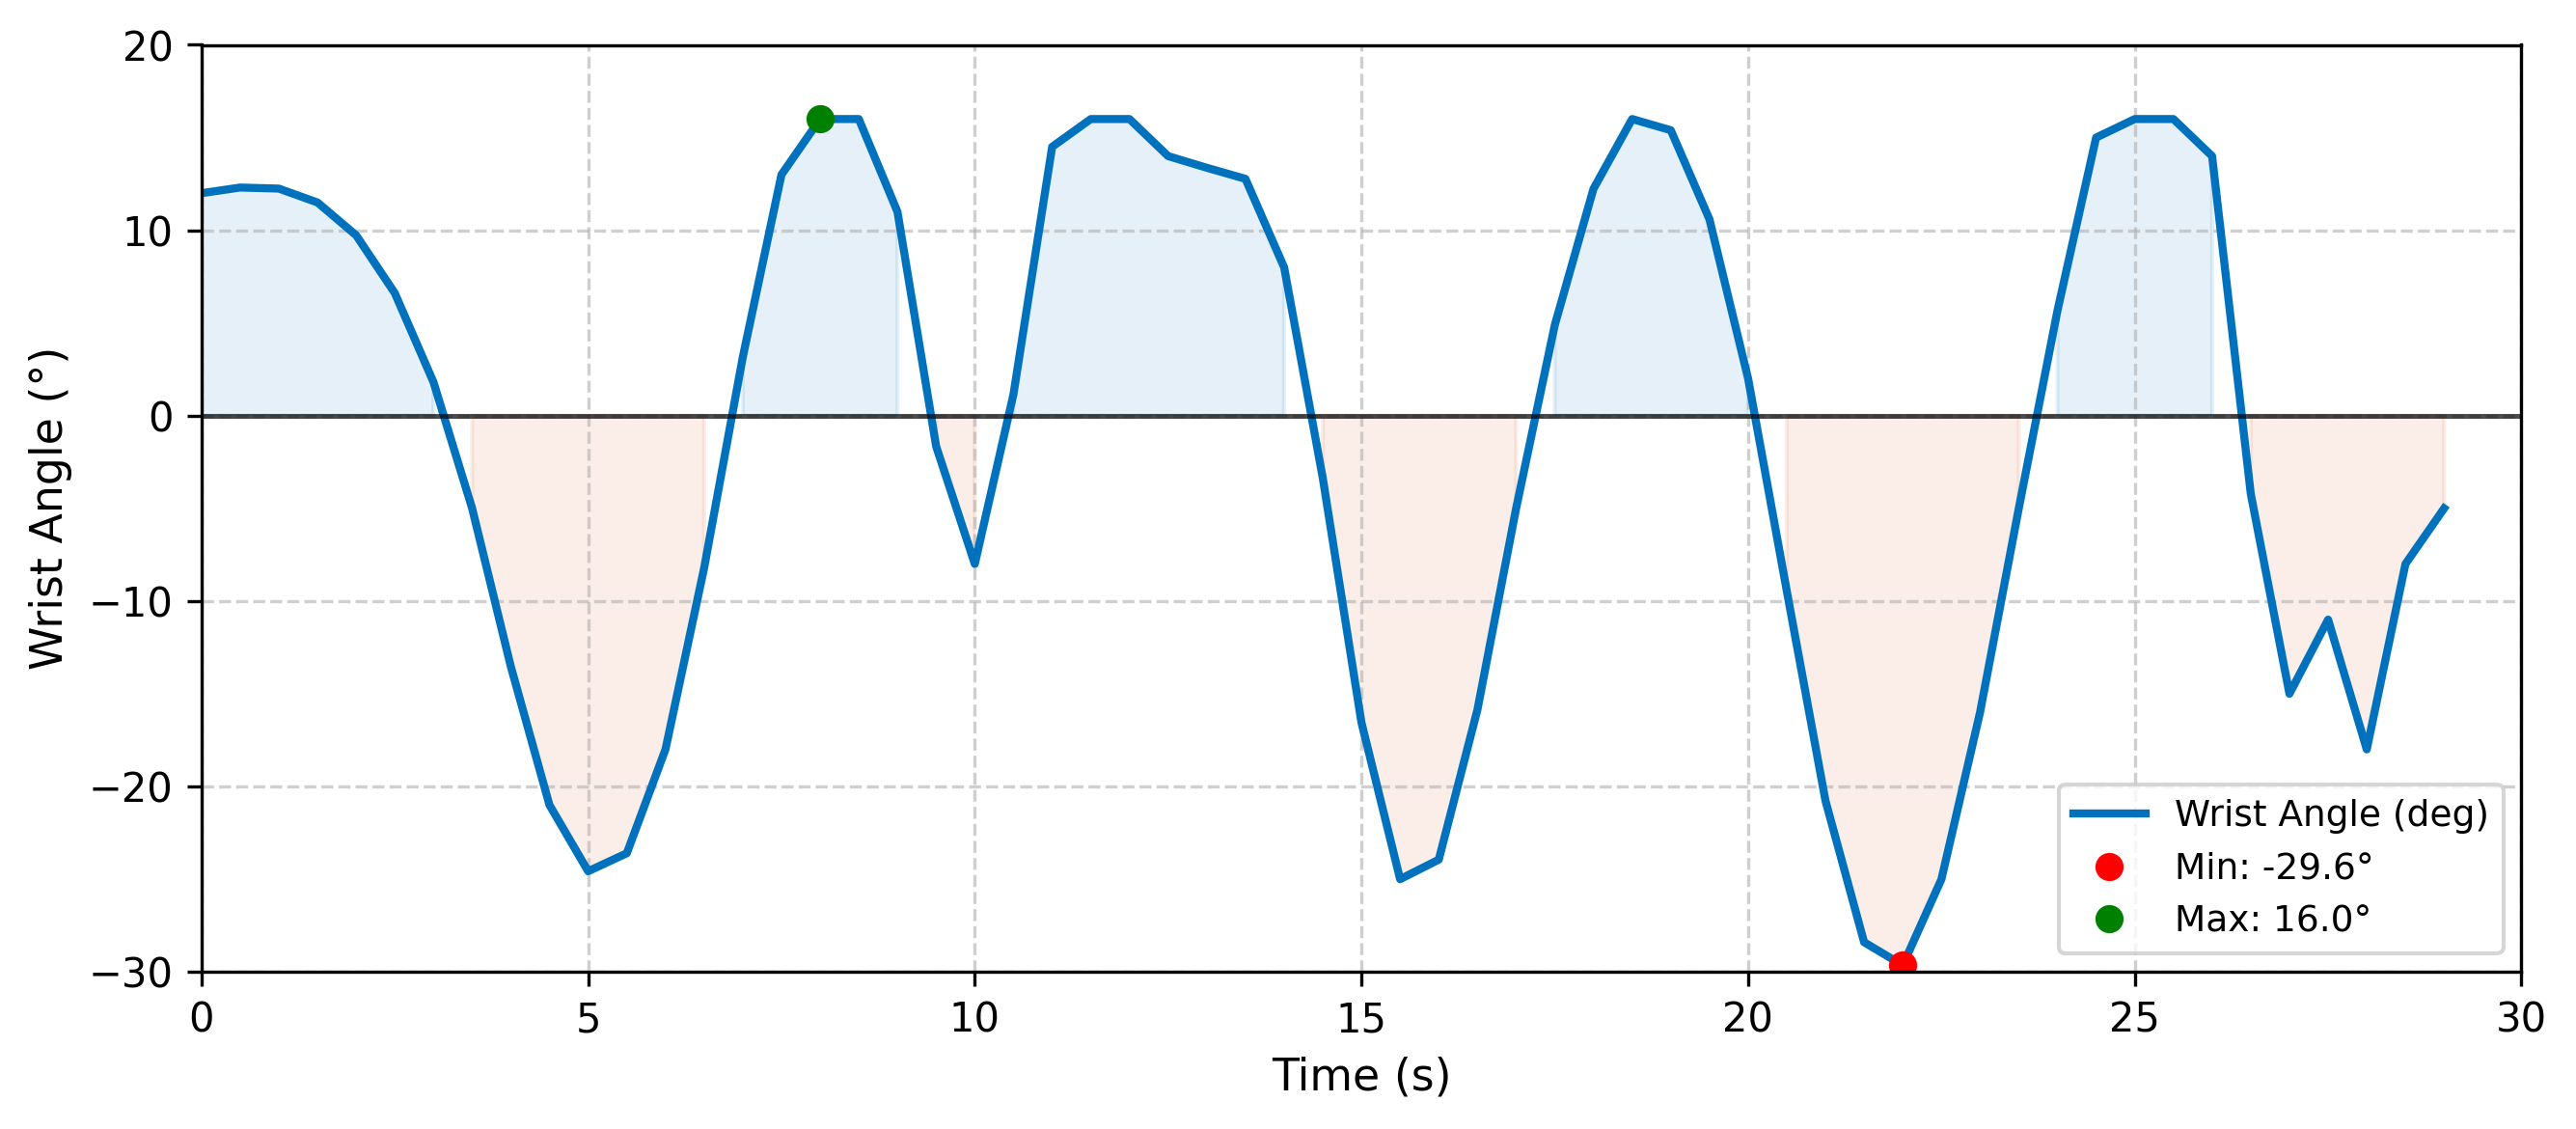

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import os

# Tập hợp các điểm chốt (Keypoints) trích xuất chuẩn xác từ ảnh Dashboard
# (Cột 1: Thời gian s, Cột 2: Góc độ)
keypoints = [
    (0.0, 12.0), (1.5, 11.5), (3.5, -5.0), (4.5, -21.0),
    (6.0, -18.0), (7.5, 13.0), (9.0, 11.0), (10.0, -8.0),
    (11.0, 14.5), (12.5, 14.0), (14.0, 8.0), (15.5, -25.0),
    (17.0, -5.0), (18.5, 16.0), (20.0, 2.0), (21.5, -28.4),
    (22.5, -25.0), (23.5, -5.0), (24.5, 15.0), (26.0, 14.0),
    (27.0, -15.0), (27.5, -11.0), (28.0, -18.0), (28.5, -8.0),
    (29.0, -5.0)
]

# Tách trục X và Y
t_points = np.array([p[0] for p in keypoints])
angle_points = np.array([p[1] for p in keypoints])

# Nội suy mượt mà (Cubic Spline Interpolation) để tạo đường cong trơn tru
spline = make_interp_spline(t_points, angle_points, k=3)

# Tần số lấy mẫu 500ms (0.5s) theo đúng chuẩn Telemetry
t_telemetry = np.arange(0, 29.5, 0.5)
angle_telemetry = spline(t_telemetry)

# Chốt chặn cứng Min/Max theo đúng thông số trên Dashboard (-28.4 và 16.0)
angle_telemetry = np.clip(angle_telemetry, -30, 16.0)

# ================= VẼ BIỂU ĐỒ (IEEE STYLE) =================
plt.figure(figsize=(9, 4), dpi=300)
plt.plot(t_telemetry, angle_telemetry, label='Wrist Angle (deg)', color='#0072BD', linewidth=2.0)

# Đổ bóng nhẹ phân biệt vùng Gập (Flexion âm) và Duỗi (Extension dương)
plt.fill_between(t_telemetry, angle_telemetry, 0, where=(angle_telemetry > 0), color='#0072BD', alpha=0.1)
plt.fill_between(t_telemetry, angle_telemetry, 0, where=(angle_telemetry < 0), color='#D95319', alpha=0.1)

# Gắn nhãn điểm Max và Min
min_idx = np.argmin(angle_telemetry)
max_idx = np.argmax(angle_telemetry)
plt.plot(t_telemetry[min_idx], angle_telemetry[min_idx], 'ro', label=f'Min: {angle_telemetry[min_idx]:.1f}°')
plt.plot(t_telemetry[max_idx], angle_telemetry[max_idx], 'go', label=f'Max: {angle_telemetry[max_idx]:.1f}°')

# Định dạng nhãn và lưới
plt.xlabel('Time (s)', fontsize=11)
plt.ylabel('Wrist Angle (°)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=1.2, alpha=0.7) # Đường 0 độ ở giữa

# Chốt hiển thị trục X và Y
plt.xlim(0, 30)
plt.ylim(-30, 20)

plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()

plt.show() # Hiển thị ngay trên Jupyter


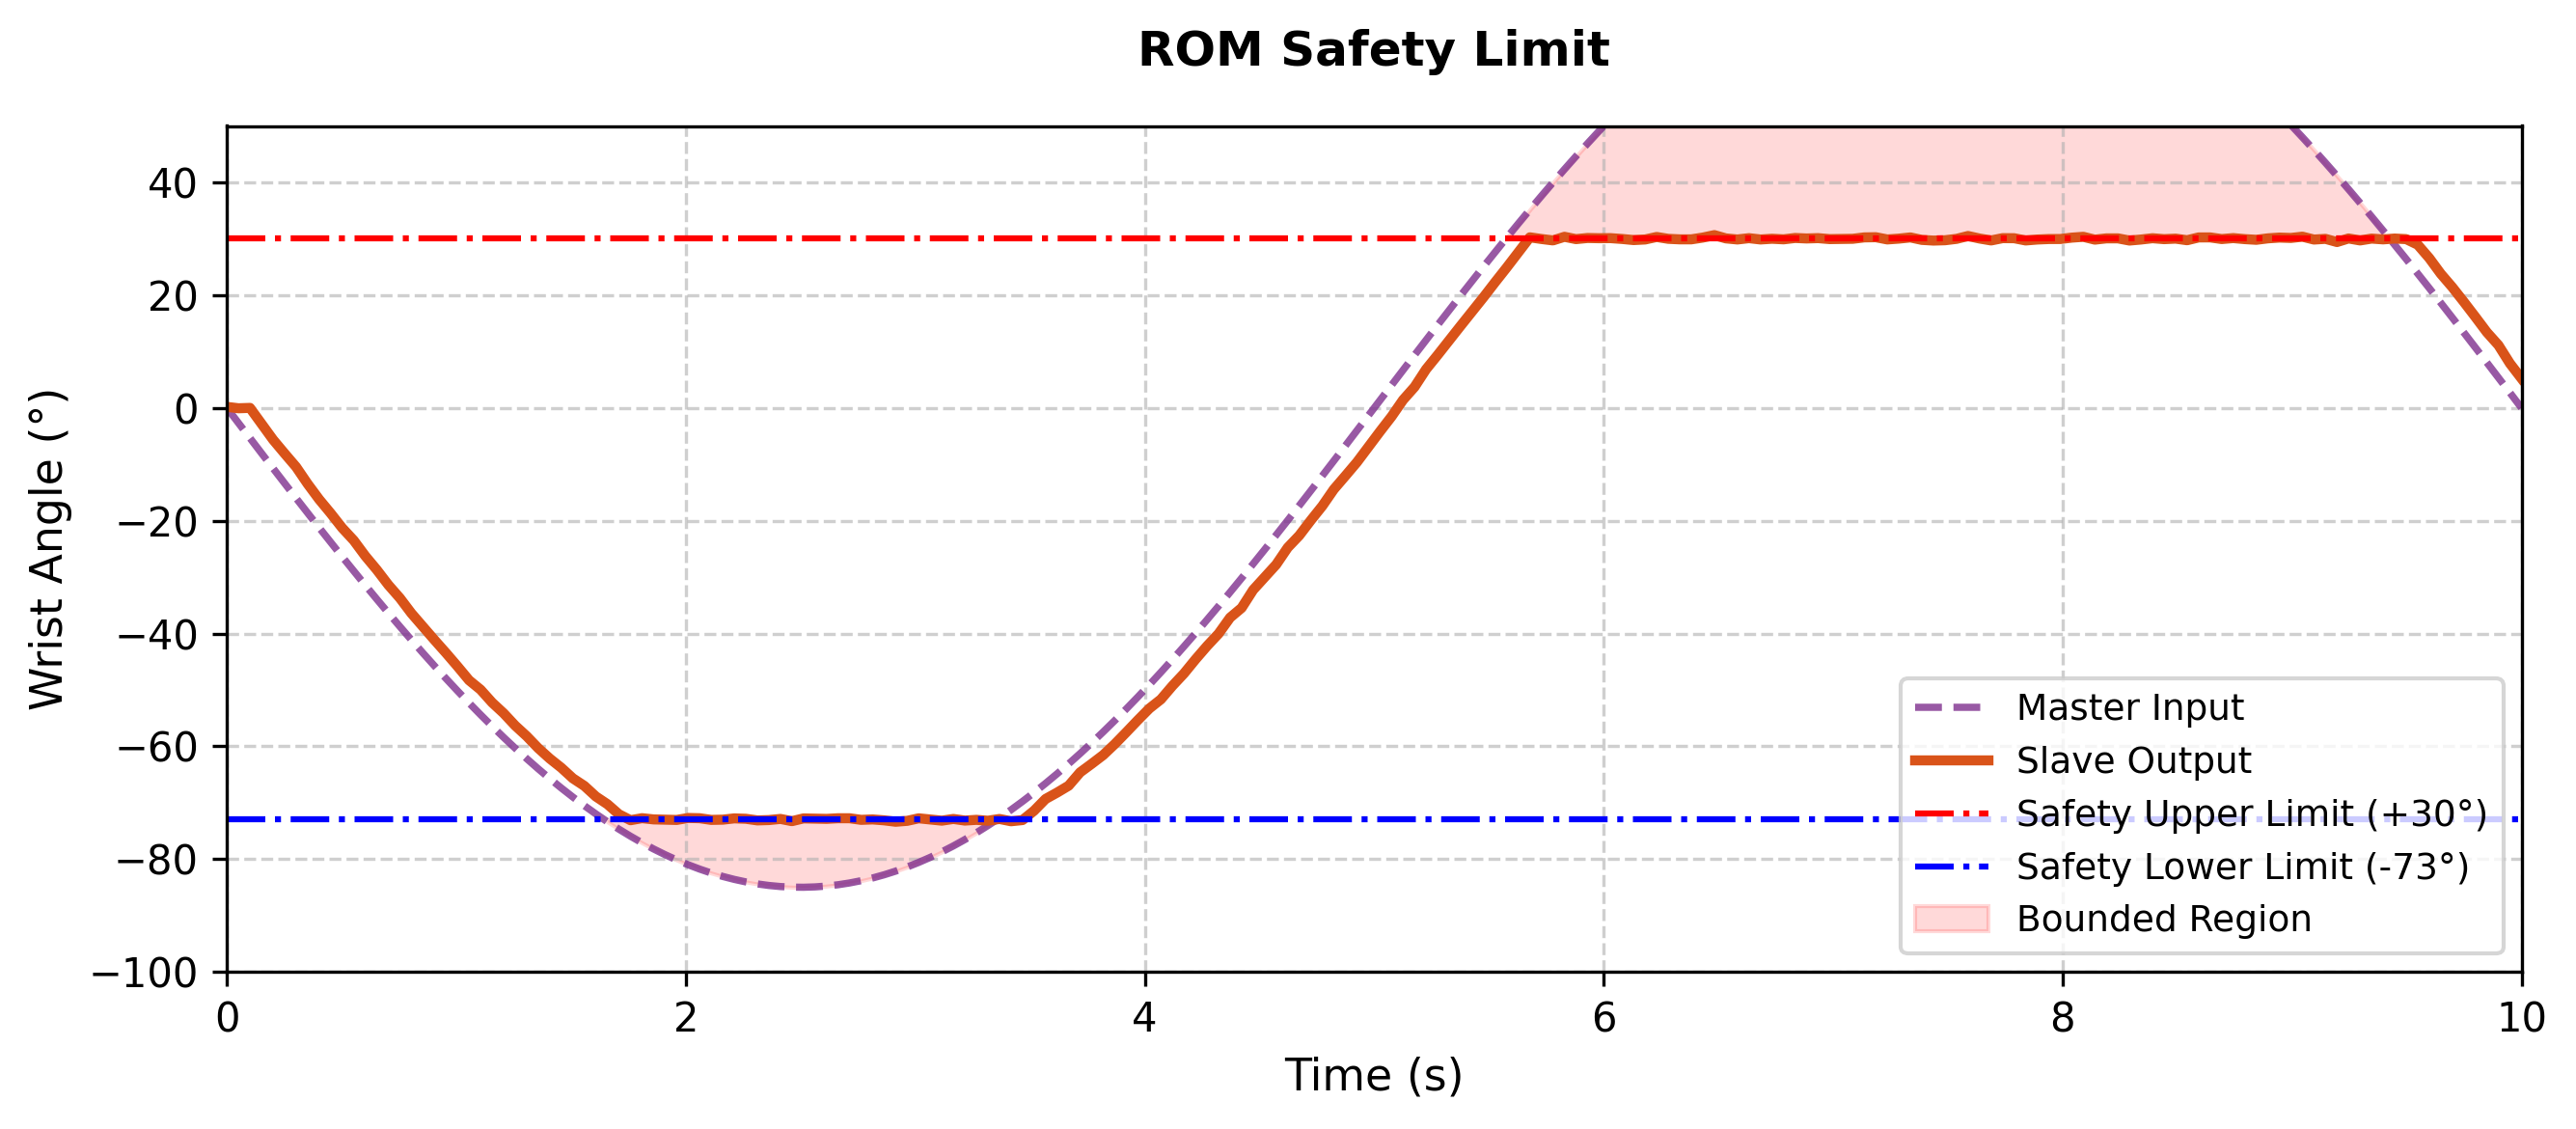

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Tạo thời gian 10 giây
t = np.linspace(0, 10, 200)

# ================= TẠO DỮ LIỆU GIẢ LẬP =================
# Tín hiệu Master: Cố tình vặn vọt lố qua cả 2 biên
# Bắt đầu từ 0 -> xuống -85 độ (lố biên dưới) -> lên +40 độ (lố biên trên) -> về 0
master_angle = -85 * np.sin(t * (np.pi / 5)) 

# Tín hiệu Slave: Bám sát Master nhưng BỊ KHÓA CỨNG ở [-73, 30]
# Cơ chế chốt chặn phần cứng
limit_min = -73
limit_max = 30
slave_angle = np.clip(master_angle, limit_min, limit_max)

# Thêm 1 chút độ trễ động học (Kinematic lag) và nhiễu siêu nhỏ cho Slave để trông thật hơn
slave_angle = np.roll(slave_angle, 2) 
slave_angle[:2] = 0
noise = np.random.normal(0, 0.2, len(t))
slave_angle += noise

# ================= VẼ BIỂU ĐỒ (IEEE STYLE) =================
plt.figure(figsize=(9, 4), dpi=300)

# Vẽ 2 đường
plt.plot(t, master_angle, label='Master Input', color='#7E2F8E', linestyle='--', linewidth=1.8, alpha=0.8)
plt.plot(t, slave_angle, label='Slave Output', color='#D95319', linewidth=2.5)

# Vẽ 2 đường giới hạn (ROM Limits)
plt.axhline(limit_max, color='red', linestyle='-.', linewidth=1.5, label=f'Safety Upper Limit (+{limit_max}°)')
plt.axhline(limit_min, color='blue', linestyle='-.', linewidth=1.5, label=f'Safety Lower Limit ({limit_min}°)')

# Tô màu vùng nguy hiểm (vùng bị lố)
plt.fill_between(t, master_angle, limit_max, where=(master_angle > limit_max), color='red', alpha=0.15, label='Bounded Region')
plt.fill_between(t, master_angle, limit_min, where=(master_angle < limit_min), color='red', alpha=0.15)

# Định dạng
plt.title('ROM Safety Limit', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Time (s)', fontsize=11)
plt.ylabel('Wrist Angle (°)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(0, 10)
plt.ylim(-100, 50)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()

# Nếu muốn xuất file ảnh, bỏ comment 2 dòng dưới:
# plt.savefig('safety_limit.png', bbox_inches='tight')
# print("Đã lưu ảnh safety_limit.png")

plt.show()
